# 05b · Hyperparameter Tuning — LSTM & GRU (Optuna)

**Project:** War Shocks & Global Financial Risk Spillover  
**Purpose:** Bayesian optimisation (TPE sampler, 30 trials each) to select
hyperparameters for LSTM and GRU. Best params saved to
`outputs/best_params_lstm.json` and `outputs/best_params_gru.json`.

**Search space** (mirrors Kumar et al. 2024 grid + standard extensions):
| Parameter | Values |
|---|---|
| hidden_size | 32, 64, 128 |
| n_layers | 1, 2 |
| dropout | 0.1, 0.2, 0.3 |
| lr | 1e-4, 1e-3, 1e-2 |
| lookback | 22, 44, 60 |

**Optimiser:** Adam + ReduceLROnPlateau + gradient clipping (norm=1.0)  
**Objective:** minimise validation MSE at h=1 (single-step)  
**Ref:** Akiba et al. (2019) *Optuna: A Next-generation HPO Framework*

In [5]:
import sys, os, json
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import torch

from src.data_loader import DATA_PROC_DIR
from src.var_models  import EQUITY_COLS
from src.lstm_models import (tune_lstm_optuna, N_FEATURES)
from src.gru_models  import  tune_gru_optuna

# ── Reproducibility ──────────────────────────────────────────────────
SEED   = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OUTPUT_DIR = os.path.join("..", "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_START = "2006-01-01"; TRAIN_END = "2018-12-31"
VAL_START   = "2019-01-01"; VAL_END   = "2021-12-31"

print(f"Device : {DEVICE}")
print(f"N_FEATURES (11): 8 vol + VIX_level + Brent_ret + Gold_ret")

Device : cpu
N_FEATURES (11): 8 vol + VIX_level + Brent_ret + Gold_ret


## 1 · Load & Build 11-Feature Matrix

Features: 8 rolling vol + VIX_level + Brent_ret + Gold_ret.  
War dummies excluded — same information set as pure VAR baseline.

In [6]:
vol_df  = pd.read_excel(f"{DATA_PROC_DIR}/rolling_volatility.xlsx",
                index_col=0, parse_dates=True)
all_vars = pd.read_excel(f"{DATA_PROC_DIR}/all_variables_aligned.xlsx",
                index_col=0, parse_dates=True)

controls = all_vars[["VIX", "Brent", "Gold"]].copy()
controls["Gold_ret"]  = np.log(controls["Gold"]  / controls["Gold"].shift(1))
controls["Brent_ret"] = np.log(controls["Brent"] / controls["Brent"].shift(1))
controls["VIX_level"] = controls["VIX"]
exog = controls[["VIX_level", "Brent_ret", "Gold_ret"]].shift(1)  # lag-1 to avoid look-ahead

common_idx    = vol_df.dropna().index
vol_clean     = vol_df.loc[common_idx, EQUITY_COLS]
exog_clean    = exog.reindex(common_idx).ffill(limit=3)
valid_mask    = exog_clean.notna().all(axis=1)
vol_clean     = vol_clean[valid_mask]
exog_clean    = exog_clean[valid_mask]
features_df   = pd.concat([vol_clean, exog_clean], axis=1)

assert features_df.shape[1] == N_FEATURES, f"Expected {N_FEATURES}, got {features_df.shape[1]}"
print(f"features_df : {features_df.shape}")
print(f"Columns     : {list(features_df.columns)}")
print(f"Date range  : {features_df.index[0].date()} ~ {features_df.index[-1].date()}")

features_df : (4016, 11)
Columns     : ['SP500_vol', 'STOXX600_vol', 'FTSE100_vol', 'DAX_vol', 'Nikkei_vol', 'HangSeng_vol', 'MSCI_EM_vol', 'CSI300_vol', 'VIX_level', 'Brent_ret', 'Gold_ret']
Date range  : 2006-03-08 ~ 2025-12-30


## 2 · Split & Scale

MinMaxScaler fitted on training data only.

In [7]:
from sklearn.preprocessing import MinMaxScaler

feat_train = features_df.loc[TRAIN_START:TRAIN_END].values
feat_val   = features_df.loc[VAL_START:VAL_END].values

scaler = MinMaxScaler(feature_range=(0, 1))
feat_train_scaled = scaler.fit_transform(feat_train)
feat_val_scaled   = scaler.transform(feat_val)

import joblib
joblib.dump(scaler, os.path.join(OUTPUT_DIR, "feature_scaler.pkl"))

print(f"Train scaled: {feat_train_scaled.shape}")
print(f"Val   scaled: {feat_val_scaled.shape}")
print("Scaler saved → outputs/feature_scaler.pkl")

Train scaled: (2608, 11)
Val   scaled: (594, 11)
Scaler saved → outputs/feature_scaler.pkl


## 3 · LSTM Optuna (30 trials)

TPE sampler minimises val MSE at h=1 across 30 trials.  
Each trial trains for up to 30 epochs with early stopping (patience=7).

In [8]:
print("Running LSTM Optuna tuning (30 trials) ...")
lstm_best_params, lstm_study = tune_lstm_optuna(
    feat_train_scaled, feat_val_scaled,
    n_trials=30, n_epochs=30, patience=7,
    n_features=N_FEATURES, device=DEVICE, seed=SEED
)

with open(os.path.join(OUTPUT_DIR, "best_params_lstm.json"), "w") as f:
    json.dump(lstm_best_params, f, indent=2)
print("\nSaved → outputs/best_params_lstm.json")

Running LSTM Optuna tuning (30 trials) ...


  0%|          | 0/30 [00:00<?, ?it/s]


LSTM Optuna best params (val MSE=0.000544)
  hidden_size    : 128
  n_layers       : 1
  dropout        : 0.2
  lr             : 0.01
  lookback       : 60

Saved → outputs/best_params_lstm.json


## 4 · GRU Optuna (30 trials)

In [9]:
print("Running GRU Optuna tuning (30 trials) ...")
gru_best_params, gru_study = tune_gru_optuna(
    feat_train_scaled, feat_val_scaled,
    n_trials=30, n_epochs=30, patience=7,
    n_features=N_FEATURES, device=DEVICE, seed=SEED
)

with open(os.path.join(OUTPUT_DIR, "best_params_gru.json"), "w") as f:
    json.dump(gru_best_params, f, indent=2)
print("\nSaved → outputs/best_params_gru.json")

Running GRU Optuna tuning (30 trials) ...


  0%|          | 0/30 [00:00<?, ?it/s]


GRU Optuna best params (val MSE=0.000476)
  hidden_size    : 128
  n_layers       : 1
  dropout        : 0.1
  lr             : 0.01
  lookback       : 60

Saved → outputs/best_params_gru.json


## 5 · Optimisation History Plot

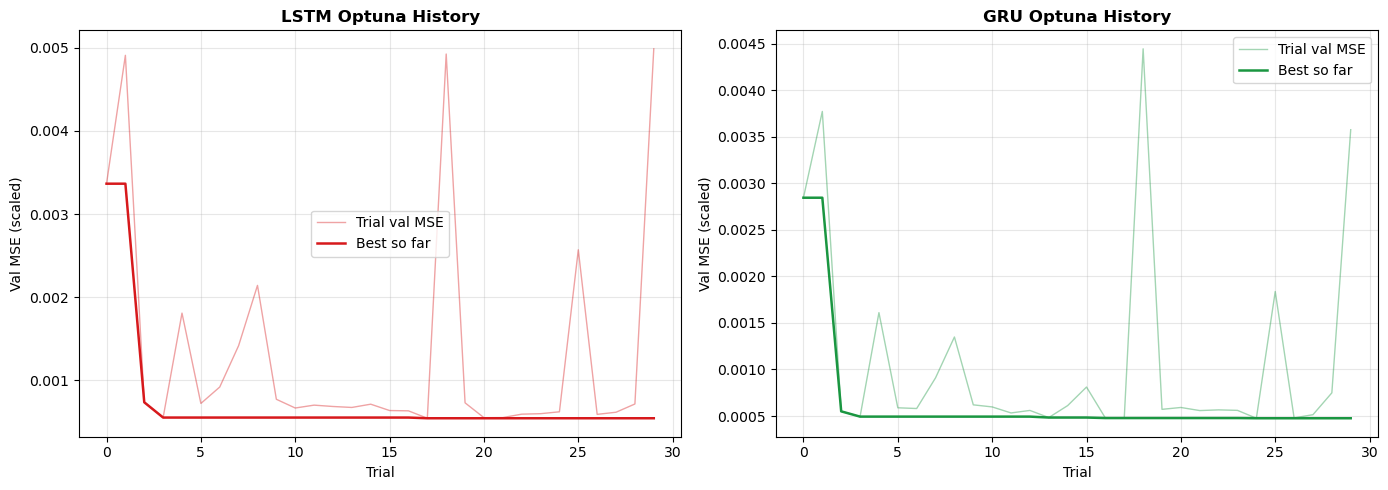

Saved → ..\outputs\figures\fig_optuna_history.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, study, name, color in [
    (axes[0], lstm_study, "LSTM", "#d7191c"),
    (axes[1], gru_study,  "GRU",  "#1a9641"),
]:
    vals = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.minimum.accumulate(vals)
    ax.plot(vals,         color=color, alpha=0.4, lw=1,   label="Trial val MSE")
    ax.plot(best_so_far,  color=color, alpha=1.0, lw=1.8, label="Best so far")
    ax.set_xlabel("Trial"); ax.set_ylabel("Val MSE (scaled)")
    ax.set_title(f"{name} Optuna History", fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, "figures", "fig_optuna_history.png")
os.makedirs(os.path.dirname(path), exist_ok=True)
plt.savefig(path, dpi=150, bbox_inches="tight"); plt.show()
print(f"Saved → {path}")

## 6 · Summary

In [ ]:
print("=" * 55)
print("TUNING SUMMARY")
print("=" * 55)
print(f"\nLSTM best val MSE : {lstm_study.best_value:.6f}")
for k, v in lstm_best_params.items():
    print(f"  {k:15s}: {v}")

print(f"\nGRU  best val MSE : {gru_study.best_value:.6f}")
for k, v in gru_best_params.items():
    print(f"  {k:15s}: {v}")

print("\nNext → 06_lstm_model.ipynb  (use best_params_lstm.json)")
print("     → 07_gru_model.ipynb   (use best_params_gru.json)")

TUNING SUMMARY

LSTM best val MSE : 0.000544
  hidden_size    : 128
  n_layers       : 1
  dropout        : 0.2
  lr             : 0.01
  lookback       : 60

GRU  best val MSE : 0.000476
  hidden_size    : 128
  n_layers       : 1
  dropout        : 0.1
  lr             : 0.01
  lookback       : 60

Next → 06_lstm_model.ipynb  (use best_params_lstm.json)
      → 07_gru_model.ipynb   (use best_params_gru.json)
